In [1]:
a=54
a

54

In [3]:
type(a)

int

In [5]:
b=4.5
b

4.5

In [7]:
type(b)

float

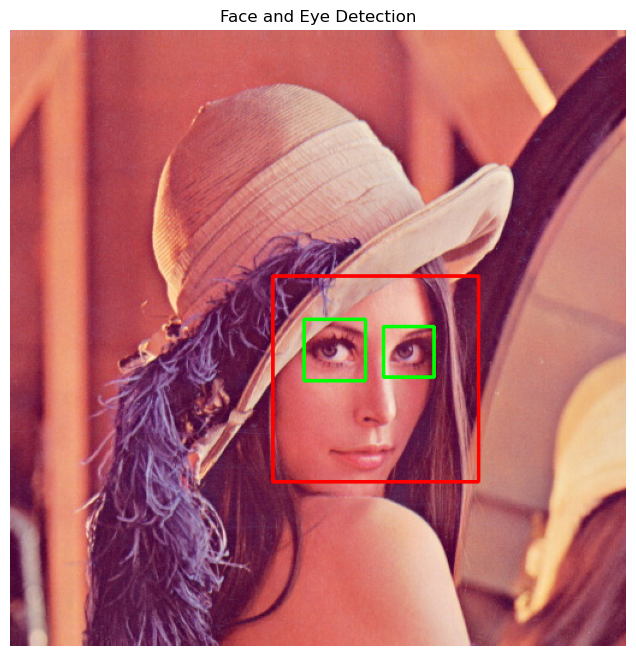

In [9]:
import cv2
import matplotlib.pyplot as plt

# Load Haar Cascade files from OpenCV
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_eye.xml"
)

# Load image (keep image in same folder as notebook)
image_path = "face.jpg"   # change image name if needed
img = cv2.imread(image_path)

if img is None:
    print("❌ Image not found. Please check the file name or path.")
else:
    # Convert image to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Detect faces
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.3,
        minNeighbors=5
    )

    # Draw rectangles
    for (x, y, w, h) in faces:
        # Face rectangle
        cv2.rectangle(img_rgb, (x, y), (x+w, y+h), (255, 0, 0), 2)

        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img_rgb[y:y+h, x:x+w]

        # Detect eyes inside face
        eyes = eye_cascade.detectMultiScale(
            roi_gray,
            scaleFactor=1.3,
            minNeighbors=5
        )

        for (ex, ey, ew, eh) in eyes:
            cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)

    # Display result
    plt.figure(figsize=(8, 8))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title("Face and Eye Detection")
    plt.show()


In [11]:
!pip install opencv-python


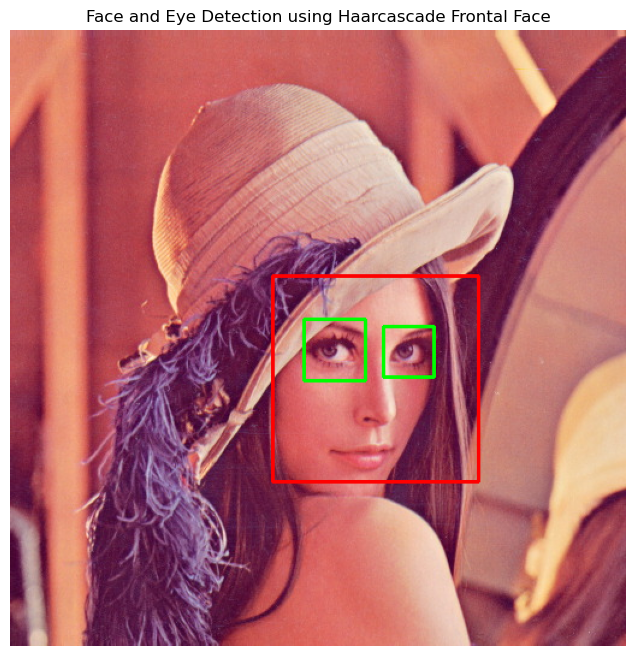

In [13]:
import cv2
import matplotlib.pyplot as plt

# Load Haarcascade frontal face & eye
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_eye.xml"
)

# Load image (keep image in same folder as notebook)
img = cv2.imread("face.jpg")   # change image name if needed

if img is None:
    print("❌ Image not found. Please check image path or filename.")
else:
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Detect faces
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.3,
        minNeighbors=5
    )

    # Draw rectangles
    for (x, y, w, h) in faces:
        # Face rectangle (BLUE)
        cv2.rectangle(img_rgb, (x, y), (x+w, y+h), (255, 0, 0), 2)

        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img_rgb[y:y+h, x:x+w]

        # Detect eyes inside face
        eyes = eye_cascade.detectMultiScale(
            roi_gray,
            scaleFactor=1.3,
            minNeighbors=5
        )

        for (ex, ey, ew, eh) in eyes:
            # Eye rectangle (GREEN)
            cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)

    # Display output
    plt.figure(figsize=(8, 8))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title("Face and Eye Detection using Haarcascade Frontal Face")
    plt.show()


In [17]:
import cv2

# Load Haarcascade files
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_eye.xml"
)

# Start webcam (0 = default camera)
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("❌ Cannot access webcam")
else:
    print("✅ Webcam started. Press 'q' to quit.")

    while True:
        ret, frame = cap.read()
        if not ret:
            print("❌ Failed to grab frame")
            break

        # Convert to grayscale
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Detect faces
        faces = face_cascade.detectMultiScale(
            gray,
            scaleFactor=1.3,
            minNeighbors=5
        )

        for (x, y, w, h) in faces:
            # Face rectangle (BLUE)
            cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)

            roi_gray = gray[y:y+h, x:x+w]
            roi_color = frame[y:y+h, x:x+w]

            # Detect eyes inside face
            eyes = eye_cascade.detectMultiScale(
                roi_gray,
                scaleFactor=1.3,
                minNeighbors=5
            )

            for (ex, ey, ew, eh) in eyes:
                # Eye rectangle (GREEN)
                cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)

        # Show webcam window
        cv2.imshow("Webcam Face & Eye Detection", frame)

        # Press 'q' to exit
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

# Release resources
cap.release()
cv2.destroyAllWindows()


✅ Webcam started. Press 'q' to quit.


In [21]:
import cv2

# Load Haarcascade files
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_eye.xml"
)

smile_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_smile.xml"
)

# Start webcam
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("❌ Cannot access webcam")
else:
    print("✅ Webcam started. Press 'q' to quit.")

    while True:
        ret, frame = cap.read()
        if not ret:
            print("❌ Failed to grab frame")
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Detect faces
        faces = face_cascade.detectMultiScale(
            gray,
            scaleFactor=1.3,
            minNeighbors=5
        )

        for (x, y, w, h) in faces:
            # Face rectangle (BLUE)
            cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)

            roi_gray = gray[y:y+h, x:x+w]
            roi_color = frame[y:y+h, x:x+w]

            # Detect eyes
            eyes = eye_cascade.detectMultiScale(
                roi_gray,
                scaleFactor=1.3,
                minNeighbors=5
            )

            for (ex, ey, ew, eh) in eyes:
                cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)

            # Detect smile (needs higher minNeighbors)
            smiles = smile_cascade.detectMultiScale(
                roi_gray,
                scaleFactor=1.8,
                minNeighbors=20
            )

            for (sx, sy, sw, sh) in smiles:
                cv2.rectangle(roi_color, (sx, sy), (sx+sw, sy+sh), (0, 0, 255), 2)
                cv2.putText(
                    frame,
                    "Smiling",
                    (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.9,
                    (0, 0, 255),
                    2
                )

        cv2.imshow("Face Eye Smile Detection", frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()


✅ Webcam started. Press 'q' to quit.


In [23]:
a=4.5
a

4.5

In [25]:
print(a)

4.5


In [27]:
print(type(a))

<class 'float'>


In [29]:
b=4.5
b

4.5

In [31]:
type(b)

float

In [33]:
c=45
c

45

In [35]:
type(c)

int

In [37]:
d="""Computer vision"""
d

'Computer vision'

In [39]:
print(d)

Computer vision


In [41]:
print(type(d))

<class 'str'>


In [43]:
type(d)

str

In [45]:
e=34
e

34

In [47]:
type(e)

int

In [49]:
e

34

In [51]:
e

34

In [53]:
type(e)

int

In [55]:
print(type(e))

<class 'int'>


In [57]:
print(type(a))

<class 'float'>


In [59]:
type(b)

float

In [61]:
print(a)

4.5


In [63]:
print(type(b))

<class 'float'>
